# Install TabPFN Extenstions

In [1]:
import importlib.util
import sys

def _missing(mod):
    return importlib.util.find_spec(mod) is None

to_install = []
# `shap` is only needed for the plotting API in the SHAP section — shapiq
# (installed via tabpfn-extensions[all]) does the actual computation.
if _missing("shap"):
    to_install.append("shap")

if to_install:
    print("Installing:", to_install)
    # `-q -q` = silence "Collecting/Downloading" progress lines.
    # `--no-warn-conflicts` = silence pre-existing Kaggle image conflicts
    # (google-colab, moviepy, bigframes, ...) that this notebook doesn't touch.
    get_ipython().run_line_magic("pip", "install -q -q --no-warn-conflicts " + " ".join(to_install))
    print("Done. If imports fail, restart the kernel and re-run.")
else:
    print("shap already available.")

shap already available.


In [2]:
print("Installing tabpfn-extensions[interpretability]... (may take ~1 minute)")
# Only the `interpretability` extra is needed for this notebook.
# `[all]` also pulls autogluon / hyperopt / llvmlite via `post_hoc_ensembles`
# + `hpo`, which are ~150 MB of unrelated deps and downgrade `pyarrow`,
# triggering the pip resolver conflict noise we don't want.
# `-q -q --no-warn-conflicts` silences "Collecting/Downloading" progress
# lines and the pre-existing Kaggle image conflict warnings (google-colab,
# moviepy, bigframes, ...) that this notebook doesn't touch.
%pip install -q -q --no-warn-conflicts "tabpfn-extensions[interpretability] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
%pip install -q -q --no-warn-conflicts "tabpfn-client"
%pip install -q -q --no-warn-conflicts "tabpfn"
print("Done. If imports fail, restart the kernel and re-run.")

Installing tabpfn-extensions[interpretability]... (may take ~1 minute)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.8/598.8 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart

### Load env

In [3]:
import os
import sys
import warnings
from contextlib import contextmanager
from io import StringIO

# Silence noisy third-party warnings that clutter the Kaggle logs but are not
# actionable here (emitted from deep inside sklearn / hyperopt during the many
# local TabPFN fits). Set once at import time so it applies to every later cell.
warnings.filterwarnings(
    "ignore",
    message=r"(?s).*remainder.*ColumnTransformer.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"(?s).*ColumnTransformer.*force_int_remainder_cols.*",
    category=FutureWarning,
)
warnings.filterwarnings("ignore", category=FutureWarning, module=r"hyperopt.*")
warnings.filterwarnings("ignore", category=UserWarning, module=r"hyperopt.*")

# Auto-detect Kaggle.
is_kaggle_env = os.path.isdir("/kaggle/working")

DEVICE = "cpu"
DEVICE_NAME = "CPU"
_gpu_note = ""

try:
    import torch

    # torch emits noisy "compute capability / sm_XX not supported" UserWarnings
    # on first CUDA touch for GPUs older than the ones the installed wheel was
    # built for (e.g. Kaggle's Tesla P100 = sm_60 with a torch built for
    # sm_70+). We handle the fallback explicitly below, so silence them.
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=r"(?s).*(compute capability|CUDA capability|sm_\d+).*",
            category=UserWarning,
        )
        if torch.cuda.is_available():
            _major, _minor = torch.cuda.get_device_capability(0)
            _gpu_name = torch.cuda.get_device_name(0)
            _supported = torch.cuda.get_arch_list()  # e.g. ['sm_70', ..., 'sm_120']
            _min_major = min(
                (int(a.removeprefix("sm_")[:-1]) for a in _supported if a.startswith("sm_")),
                default=7,
            )
            if _major >= _min_major:
                DEVICE = "cuda"
                DEVICE_NAME = _gpu_name
            else:
                # Kernel launch would crash -- fall back to CPU with a hint.
                _gpu_note = (
                    f" | note: GPU {_gpu_name} (sm_{_major}{_minor}) is below "
                    f"the installed torch build's minimum (sm_{_min_major}0) -- "
                    f"switch the Kaggle accelerator to T4 x2 for a working GPU"
                )
except Exception:
    pass


def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn
    if is_kaggle_env:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        hf = secrets.get_secret("HF_TOKEN")
        tabpfn = secrets.get_secret("FADIA_DARA_6909_TABPFN_TOKEN") or secrets.get_secret("TABPFN_TOKEN")
        return hf, tabpfn
    return hf, tabpfn

_hf_token, _tabpfn_token = _load_tabpfn_tokens()
if _tabpfn_token:
    os.environ["TABPFN_TOKEN"] = _tabpfn_token
if _hf_token:
    os.environ["HF_TOKEN"] = _hf_token

os.environ["USE_TABPFN_LOCAL"] = "false"

# Quota knobs (tabpfn-client free tier, as of 2026):
#   - 20 thinking fits
#   - 50M prediction cells / day
#   - 200M prediction cells / month
# Hybrid backend:
#   - Feature selection + PDP: local `tabpfn` on GPU/CPU (0 client API calls;
#     PDP also needs the local-only KV cache and hits a client predict_proba
#     reshape bug in sklearn's brute PDP)
#   - SHAP / SHAP-IQ: tabpfn-client + thinking (~2 thinking fits)
# USE_TABPFN_LOCAL=false keeps tabpfn_extensions on the client if imported
# elsewhere; the FS cell imports `from tabpfn import TabPFNClassifier` directly.
FS_THINKING_MODE = False
INTERP_THINKING_MODE = True
INTERP_THINKING_EFFORT = "high"
INTERP_THINKING_METRIC = "average_precision"


def _silence_client_progress(clf):
    """Prefer the official switch when present (tabpfn-client show_progress)."""
    if hasattr(clf, "show_progress"):
        clf.show_progress = False
    return clf


@contextmanager
def _quiet_tabpfn_client():
    """Discard tabpfn-client Fitting/Predicting spinner writes to stdout.

    Does not silence our own print() trackers -- only wrap fit/predict/explain
    blocks that trigger the client's run_task spinner.
    """
    _real_stdout = sys.stdout
    try:
        sys.stdout = StringIO()
        yield
    finally:
        sys.stdout = _real_stdout


print(
    f"Runtime: {'Kaggle' if is_kaggle_env else 'local'} | "
    f"TabPFN device: {DEVICE} ({DEVICE_NAME}) | "
    f"Tokens: {bool(_tabpfn_token) and bool(_hf_token)}"
    f"{_gpu_note}"
)
print(
    "Quota (client): 20 thinking fits | 50M cells/day | 200M cells/month"
)
print(
    "This notebook intends ~2 client thinking fits (SHAP, SHAP-IQ); "
    "FS + PDP use local tabpfn (0 client API calls)."
)
print(
    f"Thinking: FS/PDP={FS_THINKING_MODE} (local) | "
    f"SHAP/SHAP-IQ={INTERP_THINKING_MODE} "
    f"(effort={INTERP_THINKING_EFFORT}, metric={INTERP_THINKING_METRIC})"
)



Runtime: Kaggle | TabPFN device: cuda (Tesla T4) | Tokens: True
Quota (client): 20 thinking fits | 50M cells/day | 200M cells/month
This notebook intends ~2 client thinking fits (SHAP, SHAP-IQ); FS + PDP use local tabpfn (0 client API calls).
Thinking: FS/PDP=False (local) | SHAP/SHAP-IQ=True (effort=high, metric=average_precision)


### Load data

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_MODE = "raw"            # "raw" (spec default) or "processed"

TARGET_COL = "Stent thrombosis"
DROP_FEATURES = ["Time since stent implantation"]   # leakage control
ID_COLS = ["NO.", "Name"]
RANDOM_STATE = 42
TEST_SIZE = 0.3

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_PROCESSED_DIR = "/kaggle/input/datasets/amirmahdidaraei/preprocessed-data"
KAGGLE_RESULT_SUBDIR = "modeling_tabpfn"
RESULT_DIR = None  # resolved in the load cell

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError(
        "Could not locate data/raw/VLST.csv above the current working directory."
    )


def _discover_vlst_csv() -> Path:
    """Resolve VLST.csv on Kaggle (env override, then recursive search under /kaggle/input)."""
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)

    candidates = [
        Path(KAGGLE_RAW_CSV),
        Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
        Path("/kaggle/input/vlst-data/VLST.csv"),
        Path("/kaggle/input/VLST_data/VLST.csv"),
        Path("/kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv")
    ]
    for p in candidates:
        if p.is_file():
            return p

    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p

    raise FileNotFoundError(
        "VLST.csv not found on Kaggle. Upload it as a dataset (see §0) or set "
        "os.environ['VLST_RAW_CSV'] = '/kaggle/input/<dataset>/VLST.csv'."
    )


def _resolve_paths():
    """Return (raw_path, processed_dir, result_dir, label) for local or Kaggle."""
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        processed = Path(
            os.environ.get("VLST_PROCESSED_DIR", KAGGLE_PROCESSED_DIR)
        )
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, processed, result, f"Kaggle | raw={raw}"

    repo = _find_repo_root()
    return (
        repo / "data" / "raw" / "VLST.csv",
        repo / "data" / "processed",
        repo / "data" / "result" / "modeling_tabpfn",
        f"local | repo={repo}",
    )


RAW_PATH, PROCESSED_DIR, RESULT_DIR, _path_label = _resolve_paths()
RESULT_DIR = Path(RESULT_DIR)
PROCESSED_DIR = Path(PROCESSED_DIR)
RAW_PATH = Path(RAW_PATH)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(_path_label)
print("RAW_PATH:", RAW_PATH)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULT_DIR:", RESULT_DIR)


def load_raw():
    """Minimal, TabPFN-native handling: keep NaNs, code text columns, no scaling/one-hot."""
    df = pd.read_csv(RAW_PATH)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    y = df[TARGET_COL].astype(int).to_numpy()
    drop = [TARGET_COL] + [c for c in DROP_FEATURES if c in df.columns]
    X_df = df.drop(columns=drop)
    for c in X_df.columns:
        if X_df[c].dtype == object:
            coerced = pd.to_numeric(X_df[c].astype(str).str.strip(), errors="coerce")
            if coerced.notna().mean() >= 0.5:        # genuinely numeric (e.g. "21.00 ")
                X_df[c] = coerced
            else:                                     # categorical text -> integer codes (NOT one-hot)
                codes = X_df[c].astype("category").cat.codes.astype(float)
                X_df[c] = codes.where(codes >= 0, np.nan)
    return X_df.to_numpy(dtype=float), y, list(X_df.columns)

X_all, y_all, feature_names = load_raw()
print("Loaded RAW VLST.csv")

print(f"X: {X_all.shape} | y: {y_all.shape} | Features: {len(feature_names)}")

Kaggle | raw=/kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv
RAW_PATH: /kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv
PROCESSED_DIR: /kaggle/input/datasets/amirmahdidaraei/preprocessed-data
RESULT_DIR: /kaggle/working/modeling_tabpfn
Loaded RAW VLST.csv
X: (5185, 81) | y: (5185,) | Features: 81


### Feature selection — [1/5]

Local rankings (0 tabpfn-client calls):

1. **mutual_info_classif** — fast univariate screen → `interpretability_mutual_info_ranking.csv`
2. **TabPFN forward SFS** — model-native CV PR-AUC → `interpretability_forward_feature_selection.csv` (used by PDP)
3. **Stability selection** — forward SFS repeated over `STABILITY_N_SEEDS` resamples; per-feature selection frequency → `interpretability_feature_stability.csv` (the honesty signal for the [5/5] report)

In [5]:
"""Feature selection for VLST interpretability — local methods.

1. mutual_info_classif — fast univariate ranking (seconds, 0 TabPFN calls).
2. Local TabPFN forward SFS — CV PR-AUC with the same model family as PDP/SHAP
   (`from tabpfn import TabPFNClassifier`, not tabpfn-client).
3. Stability selection — forward SFS repeated over STABILITY_N_SEEDS resamples
   (different shuffled CV splits + seeds); we count how often each feature is
   selected. Stable features are the honest ones; a single SFS run is noisy on
   a ~2% prevalence cohort. Feeds the [5/5] consensus report.

TabPFN SFS on the *client* burns the 50M daily quota; local tabpfn avoids that.
Forward only (backward SFS removed — too costly); n_jobs=1, n_estimators=1 keeps
wall time manageable on a T4. Stability is ~STABILITY_N_SEEDS x one forward run.

CAUTION — data leakage if you reuse these features downstream:
All steps rank on the full (X_all, y_all) pool for *interpretability only*.
Treat the CSVs as exploratory guidance, not a locked-in feature mask.
PDP reads `interpretability_forward_feature_selection.csv` (TabPFN forward SFS).
"""

from __future__ import annotations

import time

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from tabpfn import TabPFNClassifier
from tabpfn_extensions import interpretability

print("=" * 60)
print("[1/5] Feature selection (mutual_info + forward SFS + stability)")
print("=" * 60)

SKIP_FS_IF_EXISTS = True

_mi_csv = RESULT_DIR / "interpretability_mutual_info_ranking.csv"
_fs_forward = RESULT_DIR / "interpretability_forward_feature_selection.csv"
_stab_csv = RESULT_DIR / "interpretability_feature_stability.csv"

N_MI_RANK = min(15, X_all.shape[1])
N_FEATURES_TO_SELECT = min(10, X_all.shape[1])
STABILITY_N_SEEDS = 5                       # resamples for stability selection
STABILITY_K = N_FEATURES_TO_SELECT          # features kept per resample
FS_CV = 5
FS_N_JOBS = 1
FS_N_ESTIMATORS = 1


def _make_fs_clf():
    return TabPFNClassifier(
        device=DEVICE,
        n_estimators=FS_N_ESTIMATORS,
        random_state=RANDOM_STATE,
    )


_t0 = time.perf_counter()

# --- 1a. Mutual information (univariate) ---------------------------------
print("\n--- [1a] mutual_info_classif ---")
if SKIP_FS_IF_EXISTS and _mi_csv.is_file():
    print(f"Skipping MI ranking — already saved at {_mi_csv}")
    print("(Delete the CSV to re-run.)")
    _mi_ranked = pd.read_csv(_mi_csv)
else:
    print(
        f"Ranking {X_all.shape[1]} features with mutual_info_classif "
        f"(top {N_MI_RANK})..."
    )
    _col_med = np.nanmedian(X_all, axis=0)
    _X_mi = np.where(np.isnan(X_all), _col_med, X_all)
    _mi = mutual_info_classif(
        _X_mi,
        y_all,
        discrete_features=False,
        random_state=RANDOM_STATE,
    )
    _order = np.argsort(_mi)[::-1]
    _top = _order[:N_MI_RANK]
    _mi_ranked = pd.DataFrame(
        {
            "rank": range(1, len(_top) + 1),
            "feature": [feature_names[i] for i in _top],
            "mutual_info": [_mi[i] for i in _top],
        },
    )
    _mi_ranked.to_csv(_mi_csv, index=False)
    print(f"Top {N_MI_RANK}: {_mi_ranked['feature'].tolist()}")
    print(f"Saved: {_mi_csv}")

# --- 1b. Local TabPFN forward sequential FS -----------------------------
print("\n--- [1b] local TabPFN forward SFS ---")
if SKIP_FS_IF_EXISTS and _fs_forward.is_file():
    print(f"Skipping TabPFN forward SFS — already saved at {_fs_forward}")
    print("(Delete the CSV to re-run.)")
    _tabpfn_ranked = pd.read_csv(_fs_forward)
    print(f"Loaded {len(_tabpfn_ranked)} selected features from existing CSV.")
else:
    print(
        f"Forward SFS: select {N_FEATURES_TO_SELECT} of {X_all.shape[1]} features, "
        f"cv={FS_CV}, device={DEVICE} (local tabpfn; 0 client API calls)..."
    )

    result = interpretability.feature_selection.feature_selection(
        estimator=_make_fs_clf(),
        X=X_all,
        y=y_all,
        n_features_to_select=N_FEATURES_TO_SELECT,
        feature_names=list(feature_names),
        cv=FS_CV,
        scoring="average_precision",
        direction="forward",
        n_jobs=FS_N_JOBS,
        tol=0.0001,
        verbose=True,
    )

    print("\nProgrammatic summary (forward):")
    print(f"Selected features ({len(result.selected_names)}): {result.selected_names}")
    print(
        f"CV score before / after: "
        f"{result.baseline_score_mean:.4f} -> {result.selected_score_mean:.4f}"
    )

    _tabpfn_ranked = pd.DataFrame(
        {
            "rank": range(1, len(result.selected_names) + 1),
            "feature": result.selected_names,
        },
    )
    _tabpfn_ranked.to_csv(_fs_forward, index=False)
    print(f"Saved: {_fs_forward}")

# --- 1c. Stability selection: repeated forward SFS ----------------------
# Repeat forward SFS over STABILITY_N_SEEDS resamples (shuffled stratified CV
# + varied estimator seed) and count how often each feature is selected.
# Selection frequency is the honest "is this feature reliably important?"
# signal — a single SFS run is noisy on a small, imbalanced cohort.
print("\n--- [1c] stability selection (repeated forward SFS) ---")
if SKIP_FS_IF_EXISTS and _stab_csv.is_file():
    print(f"Skipping stability selection — already saved at {_stab_csv}")
    print("(Delete the CSV to re-run.)")
    _stability = pd.read_csv(_stab_csv)
    print(f"Loaded stability for {len(_stability)} features from existing CSV.")
else:
    print(
        f"Repeating forward SFS over {STABILITY_N_SEEDS} resamples "
        f"(select {STABILITY_K} of {X_all.shape[1]}, cv={FS_CV}, device={DEVICE}). "
        f"Cost ≈ {STABILITY_N_SEEDS}x one forward SFS — local tabpfn, "
        f"0 client API calls."
    )
    _counts = np.zeros(X_all.shape[1], dtype=int)
    for _s in range(STABILITY_N_SEEDS):
        _seed = RANDOM_STATE + _s
        _cv = StratifiedKFold(n_splits=FS_CV, shuffle=True, random_state=_seed)
        _clf = TabPFNClassifier(
            device=DEVICE,
            n_estimators=FS_N_ESTIMATORS,
            random_state=_seed,
        )
        _res = interpretability.feature_selection.feature_selection(
            estimator=_clf,
            X=X_all,
            y=y_all,
            n_features_to_select=STABILITY_K,
            feature_names=list(feature_names),
            cv=_cv,
            scoring="average_precision",
            direction="forward",
            n_jobs=FS_N_JOBS,
            verbose=False,
        )
        _counts[_res.selected_indices] += 1
        print(
            f"  seed {_s + 1}/{STABILITY_N_SEEDS} (rs={_seed}): "
            f"{_res.selected_names}"
        )

    _stability = pd.DataFrame(
        {
            "feature": list(feature_names),
            "times_selected": _counts,
            "selection_freq": _counts / STABILITY_N_SEEDS,
        },
    )
    _stability = (
        _stability[_stability["times_selected"] > 0]
        .sort_values(["selection_freq", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )
    _stability.insert(0, "rank", range(1, len(_stability) + 1))
    _stability.to_csv(_stab_csv, index=False)
    print(f"Saved per-feature stability: {_stab_csv}")

# Breakdown: how many features were kept in exactly k of the STABILITY_N_SEEDS
# runs (printed whether freshly computed or loaded), plus a summary CSV.
_stab_summary_csv = RESULT_DIR / "interpretability_feature_stability_summary.csv"
print(f"\nSelection-frequency breakdown (out of {STABILITY_N_SEEDS} runs):")
_summary_rows = []
for _k in range(STABILITY_N_SEEDS, 0, -1):
    _feats = _stability.loc[_stability["times_selected"] == _k, "feature"].tolist()
    print(f"  selected {_k}/{STABILITY_N_SEEDS}x  ({len(_feats)} features): {_feats}")
    _summary_rows.append(
        {
            "times_selected": _k,
            "n_features": len(_feats),
            "features": "; ".join(_feats),
        },
    )
pd.DataFrame(_summary_rows).to_csv(_stab_summary_csv, index=False)
print(f"Saved breakdown: {_stab_summary_csv}")

_elapsed = time.perf_counter() - _t0
print(
    f"\n[1/5] done in {_elapsed:.1f}s | "
    f"MI: {_mi_csv} | forward: {_fs_forward} | stability: {_stab_csv}"
)




[1/5] Feature selection (mutual_info + forward SFS + stability)

--- [1a] mutual_info_classif ---
Ranking 81 features with mutual_info_classif (top 15)...
Top 15: ['CaI', 'WBC', 'LV', 'Stent type-SES', 'eGFR', '1.1:1Post dilation', 'LDL', 'No postdilation', 'HbA1c', 'HGB', 'Fast-Glu', 'TCL', 'Fiberinogen', 'ZES', 'Visual thrombus']
Saved: /kaggle/working/modeling_tabpfn/interpretability_mutual_info_ranking.csv

--- [1b] local TabPFN forward SFS ---
Forward SFS: select 10 of 81 features, cv=5, device=cuda (local tabpfn; 0 client API calls)...
Feature selection: direction='forward', cv=5, scoring='average_precision', n_features_to_select=10


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Baseline CV score on all 81 features: 0.3669 ± 0.1971
  round 1/10: picked feature 'WBC', cv score = 0.3977
  round 2/10: picked feature 'TIMI-2', cv score = 0.4714
  round 3/10: picked feature 'Staged PCI', cv score = 0.3138
  round 4/10: picked feature 'Slow flow', cv score = 0.3793
  round 5/10: picked feature 'Lesion location-Ostial', cv score = 0.3828
  round 6/10: picked feature 'History of HF', cv score = 0.3917
  round 7/10: picked feature 'P-LM', cv score = 0.4170
  round 8/10: picked feature 'Visual thrombus', cv score = 0.3434
  round 9/10: picked feature 'History of peripheral vascualr disease', cv score = 0.2962
  round 10/10: picked feature 'Ticagrelor', cv score = 0.3806
Selected 10 feature(s): ['History of peripheral vascualr disease', 'History of HF', 'Lesion location-Ostial', 'Visual thrombus', 'P-LM', 'TIMI-2', 'Staged PCI', 'Slow flow', 'WBC', 'Ticagrelor']
CV score on selected features: 0.3806 ± 0.2093

Programmatic summary (forward):
Selected features (10): ['Hist

### PDP (Partial Dependence Plot) Part

[2/5] PDP (Partial Dependence Plots)
Fitting local TabPFN for PDP (KV cache; 0 client thinking fits)...
Computing PDP: features=['WBC'], grid_resolution=30...


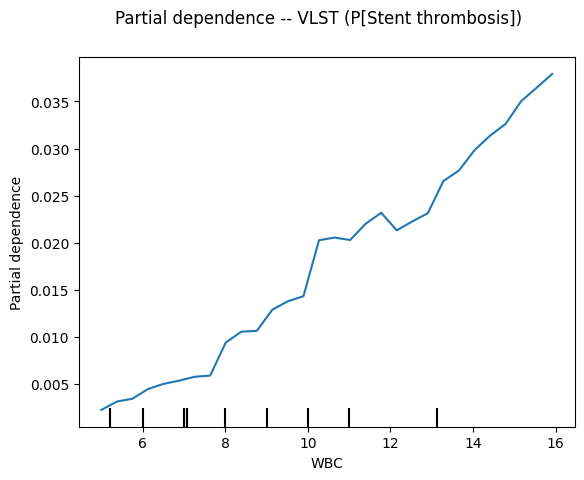

Saved: /kaggle/working/modeling_tabpfn/interpretability_pdp.png
[2/5] done in 42.9s | artifact: /kaggle/working/modeling_tabpfn/interpretability_pdp.png


In [6]:
"""Partial dependence plots for the VLST TabPFN classifier — LOCAL tabpfn.

PDP runs on the local `tabpfn` package, NOT tabpfn-client:
  - Speed/quota: PDP issues many predicts against the same fitted model; the KV
    cache (`fit_mode='fit_with_cache'`, local-only) reuses the encoder pass over
    X_train per grid point. The client can't provide it and would burn quota.
  - Trade-off: local tabpfn has no `thinking_mode`. PDP shows the base model's
    response surface, where thinking adds little; SHAP / SHAP-IQ keep thinking.

IMPORTANT — binary features crash sklearn's PDP:
`ValueError: cannot reshape array of size 1 into shape (2)`. This is a general
scikit-learn edge case, NOT TabPFN-specific: `_get_response_values` returns a
1-D array for a binary classifier, so a *binary feature* yields a 2-point grid
and `averaged_predictions` of shape (2,); sklearn misreads that 2 as "2 classes"
and collapses it, breaking the final reshape. So we compute 1-D PDPs only for
features with >2 unique values (continuous), where a PD *curve* is meaningful
anyway. The whole section is wrapped in try/except so any residual failure only
logs and lets the later SHAP / SHAP-IQ sections run.
"""

from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier
from tabpfn_extensions.interpretability.pdp import partial_dependence_plots

print("=" * 60)
print("[2/5] PDP (Partial Dependence Plots)")
print("=" * 60)

SKIP_PDP_IF_EXISTS = True
pdp_out = RESULT_DIR / "interpretability_pdp.png"

_t0 = time.perf_counter()

if SKIP_PDP_IF_EXISTS and pdp_out.is_file():
    print(f"Skipping PDP -- already saved at {pdp_out}")
else:
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all,
            test_size=TEST_SIZE,
            stratify=y_all,           # VLST is imbalanced -- always stratify
            random_state=RANDOM_STATE,
        )

        def _make_pdp_clf(**extra):
            # Local tabpfn -- pass `**extra` through so fit_mode reaches the model.
            return TabPFNClassifier(
                device=DEVICE,
                random_state=RANDOM_STATE,
                **extra,
            )

        print("Fitting local TabPFN for PDP (KV cache; 0 client thinking fits)...")
        try:
            clf = _silence_client_progress(_make_pdp_clf(fit_mode="fit_with_cache"))
            with _quiet_tabpfn_client():
                clf.fit(X_train, y_train)
            if hasattr(clf, "executor_"):
                clf.executor_.keep_cache_on_device = True
        except (TypeError, ValueError, NotImplementedError):
            warnings.warn(
                "PDP would benefit substantially from the KV cache, but this "
                "tabpfn version doesn't support fit_mode='fit_with_cache'. "
                "Upgrade with `pip install -U tabpfn` for a substantial speedup. "
                "Falling back to the default constructor.",
                UserWarning,
                stacklevel=2,
            )
            clf = _silence_client_progress(_make_pdp_clf())
            with _quiet_tabpfn_client():
                clf.fit(X_train, y_train)

        # Pick 1-D PD features with >2 unique values. Binary features crash
        # sklearn's brute PDP (see module docstring) and a 2-point "curve" is
        # uninformative anyway. Prefer the FS ranking, keep only continuous
        # ones, else fall back to the globally most-varied features.
        def _n_unique(idx):
            col = X_test[:, idx]
            return int(np.unique(col[~np.isnan(col)]).size)

        _fs_csv = RESULT_DIR / "interpretability_forward_feature_selection.csv"
        if _fs_csv.is_file():
            _ranked = pd.read_csv(_fs_csv)["feature"].tolist()
        else:
            _ranked = list(feature_names)
        _cont = [n for n in _ranked if _n_unique(feature_names.index(n)) > 2]
        if not _cont:
            _cont = [
                n
                for n in sorted(
                    feature_names,
                    key=lambda n: _n_unique(feature_names.index(n)),
                    reverse=True,
                )
                if _n_unique(feature_names.index(n)) > 2
            ]
        if not _cont:
            raise ValueError(
                "No feature with >2 unique values available for a 1-D PDP curve."
            )

        _pd_names = _cont[:3]
        _pd_idx = [feature_names.index(n) for n in _pd_names]

        # One pairwise interaction between the two strongest continuous features
        # (continuous x continuous also avoids the 2-point grid collision).
        pd_features = list(_pd_idx)
        _interact_partner = None
        if len(_cont) >= 2:
            _interact_partner = _cont[1]
            pd_features = _pd_idx + [
                (_pd_idx[0], feature_names.index(_interact_partner))
            ]

        _msg = f"Computing PDP: features={_pd_names}"
        if _interact_partner is not None:
            _msg += f" + interaction ({_pd_names[0]}, {_interact_partner})"
        print(_msg + ", grid_resolution=30...")

        with _quiet_tabpfn_client():
            disp = partial_dependence_plots(
                estimator=clf,
                X=X_test,
                features=pd_features,
                grid_resolution=30,
                kind="average",
                target_class=1,       # positive class = "Stent thrombosis"
                feature_names=list(feature_names),
            )
        disp.figure_.suptitle("Partial dependence -- VLST (P[Stent thrombosis])")

        plt.savefig(pdp_out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {pdp_out}")
    except Exception as _pdp_err:
        import traceback

        print(
            f"[2/5] PDP FAILED — logging and continuing to the next section. "
            f"{type(_pdp_err).__name__}: {_pdp_err}"
        )
        traceback.print_exc()

_elapsed = time.perf_counter() - _t0
print(f"[2/5] done in {_elapsed:.1f}s | artifact: {pdp_out}")




### SHAP Part

[3/5] SHAP (SV + one-row k-SII)
Fitting TabPFN for SHAP (1 thinking fit)...


Train set already exists, skipping upload.
/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py:218: UserWarning: Imputation-based SHAP would benefit substantially from the KV cache, but the tabpfn-client backend does not currently support it. Install the local tabpfn package (`pip install tabpfn`) and use TabPFNClassifier/TabPFNRegressor with fit_mode='fit_with_cache' to enable it.
  return fn(*args, **kwargs)


00:00 Predicting... \

Test set already exists, skipping upload.


00:09 Predicting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:09 Predicting... Done!
Explaining 15/15 rows, budget=256, imputer=baseline...
SHAP row 1/15 done
SHAP row 2/15 done
SHAP row 3/15 done
SHAP row 4/15 done
SHAP row 5/15 done
SHAP row 6/15 done
SHAP row 7/15 done
SHAP row 8/15 done
SHAP row 9/15 done
SHAP row 10/15 done
SHAP row 11/15 done
SHAP row 12/15 done
SHAP row 13/15 done
SHAP row 14/15 done
SHAP row 15/15 done
Saved SHAP mean(|SV|) ranking: /kaggle/working/modeling_tabpfn/interpretability_shap_mean_abs.csv


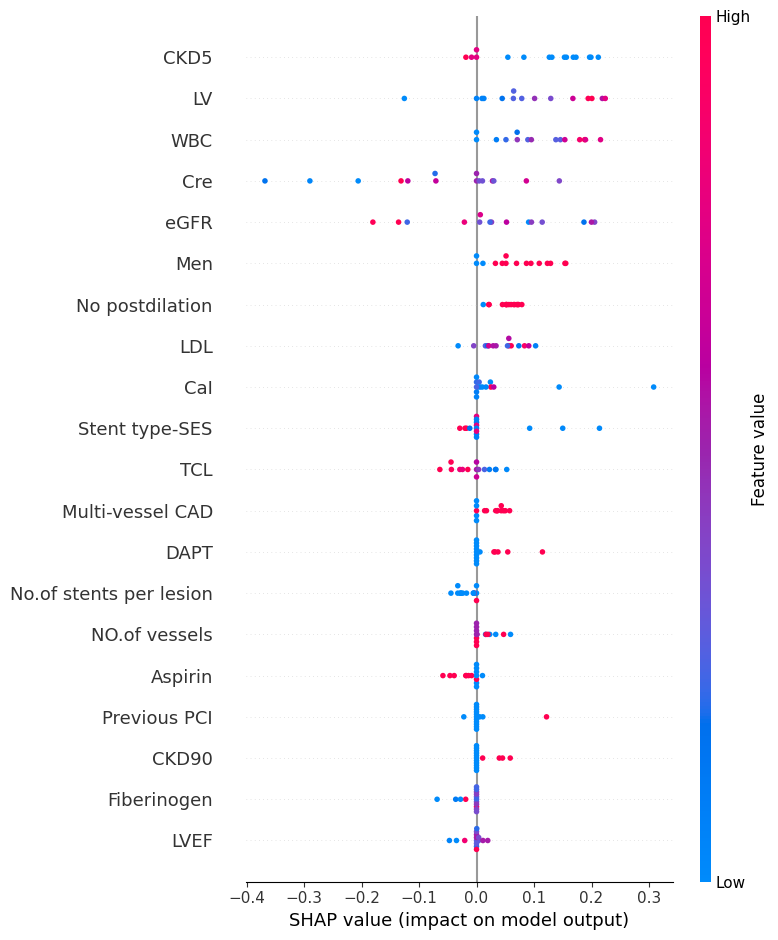

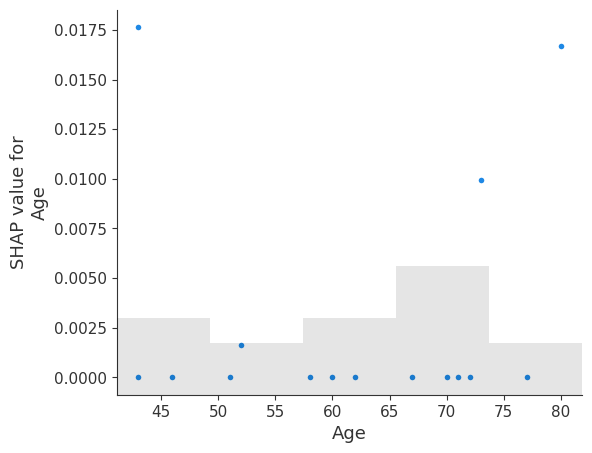

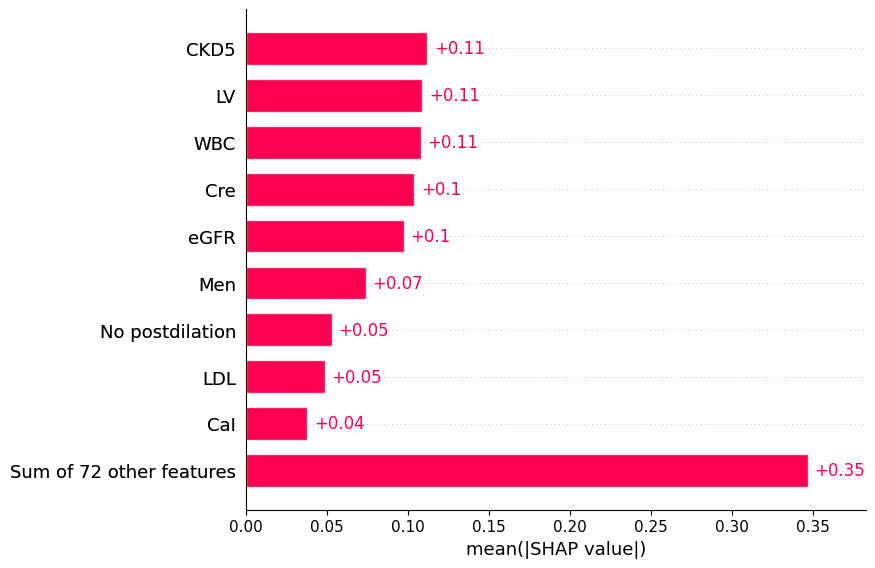

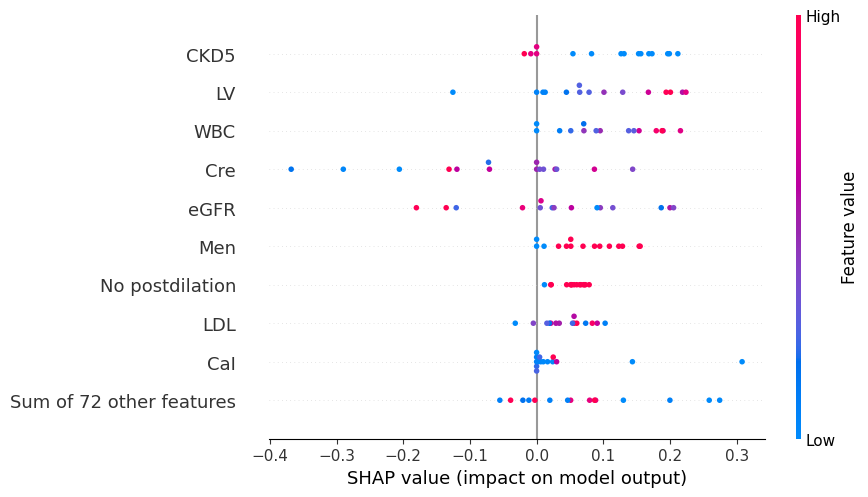

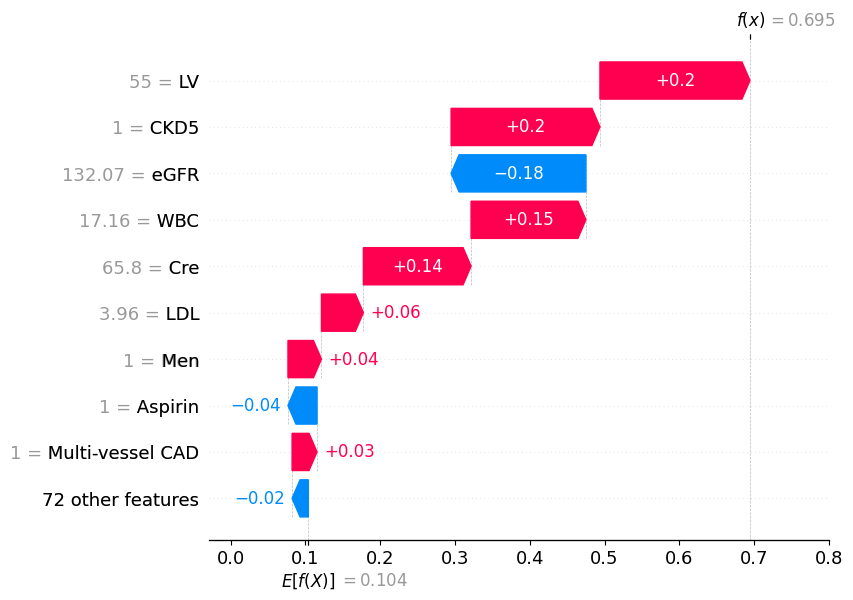

SHAP plots saved under: /kaggle/working/modeling_tabpfn


/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py:218: UserWarning: Imputation-based SHAP would benefit substantially from the KV cache, but the tabpfn-client backend does not currently support it. Install the local tabpfn package (`pip install tabpfn`) and use TabPFNClassifier/TabPFNRegressor with fit_mode='fit_with_cache' to enable it.
  return fn(*args, **kwargs)


00:00 Predicting... \

Test set already exists, skipping upload.


00:08 Predicting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:07 Predicting... Done!
Computing pairwise Shapley interactions (k-SII, budget=256)...


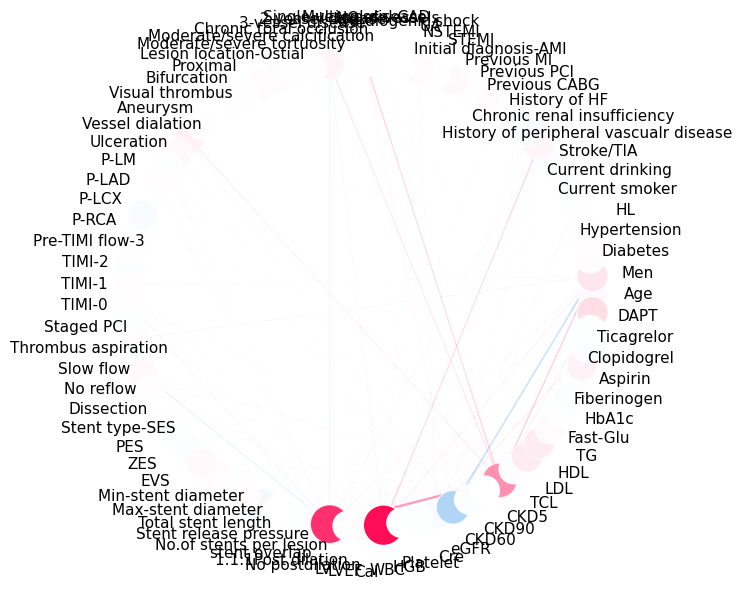

<Figure size 640x480 with 0 Axes>

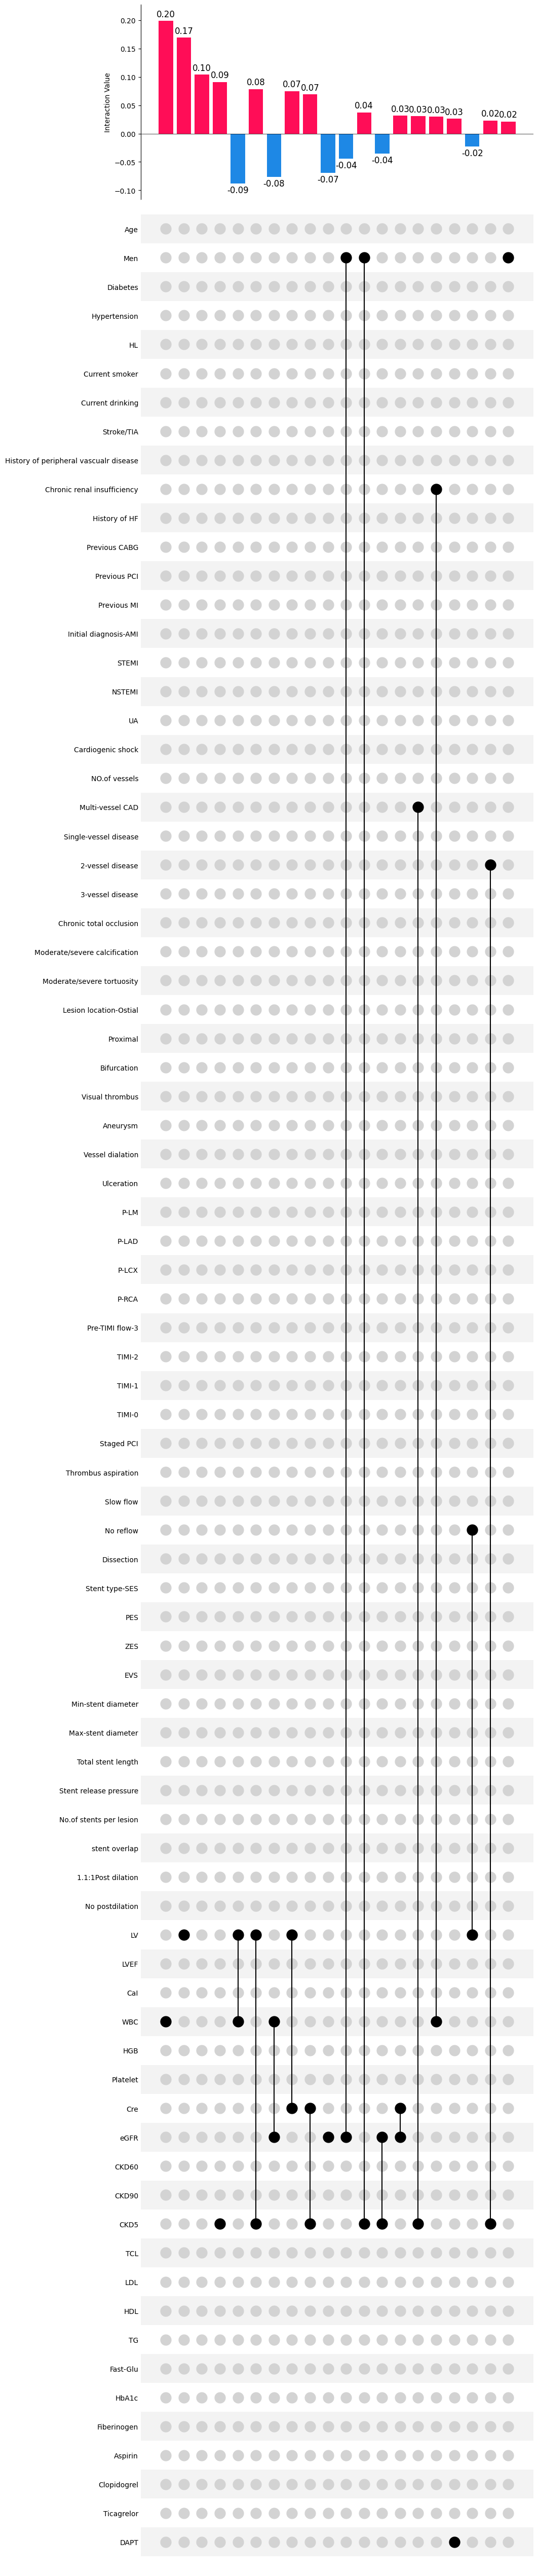

<Figure size 640x480 with 0 Axes>

k-SII interaction plots saved under: /kaggle/working/modeling_tabpfn
[3/5] done in 466.3s | artifacts under: /kaggle/working/modeling_tabpfn


In [7]:
"""SHAP values for the VLST TabPFN classifier via shapiq, visualized with
the SHAP library's plotting API.

We use shapiq for the actual Shapley-value computation (faster and
extension-friendly for TabPFN) but the SHAP library's plotting ecosystem
is mature. This bridges the two: wrap shapiq output in a
`shap.Explanation` and call `shap.plots.*` / `shap.summary_plot`.

For k-SII (pairwise interactions), standard SHAP plots only show first-order
effects -- the k-SII block below uses shapiq's native `plot_network` /
`plot_upset` instead.

For a classifier, `get_tabpfn_imputation_explainer` defaults to
`class_index=1` -- the positive class. That's what we want on VLST (target
= "Stent thrombosis").

The `shap` package is not part of the `interpretability` extra (we depend
on shapiq for compute). It's installed by the top-of-notebook install
cell.

VLST has ~50 features, so 2**d exact enumeration is astronomical -- the
budget below samples coalitions instead. Increase it on GPU for tighter
estimates.

The TabPFN model is constructed with `fit_mode="fit_with_cache"` to
engage the KV cache, which speeds up Shapley-value computation by one to
two orders of magnitude; the shapiq wrapper warns if the cache isn't
enabled.
"""

from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from tabpfn_client import TabPFNClassifier
from tabpfn_extensions.interpretability import shapiq as tabpfn_shapiq

print("=" * 60)
print("[3/5] SHAP (SV + one-row k-SII)")
print("=" * 60)

SKIP_SHAP_IF_EXISTS = True
_shap_meanabs_csv = RESULT_DIR / "interpretability_shap_mean_abs.csv"
_shap_plots = [
    RESULT_DIR / "sv_interpretability_shap_summary.png",
    RESULT_DIR / "sv_interpretability_shap_scatter_f0.png",
    RESULT_DIR / "sv_interpretability_shap_bar.png",
    RESULT_DIR / "sv_interpretability_shap_beeswarm.png",
    RESULT_DIR / "sv_interpretability_shap_waterfall_row0.png",
    RESULT_DIR / "k_ssi_interpretability_network.png",
    RESULT_DIR / "k_ssi_interpretability_upset.png",
    _shap_meanabs_csv,
]

_t0 = time.perf_counter()

if SKIP_SHAP_IF_EXISTS and all(p.is_file() for p in _shap_plots):
    print(
        "Skipping SHAP -- all plot artifacts already exist under "
        f"{RESULT_DIR}"
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=TEST_SIZE,
        stratify=y_all,
        random_state=RANDOM_STATE,
    )

    # Explain positives first so the beeswarm/waterfall highlight the
    # minority (informative) class before falling back to negatives.
    _pos_idx = np.where(y_test == 1)[0]
    _neg_idx = np.where(y_test == 0)[0]
    SHAP_N_EXPLAIN = min(15, X_test.shape[0])
    _order = np.concatenate([_pos_idx, _neg_idx])[:SHAP_N_EXPLAIN]
    X_explain = X_test[_order]

    def _make_shap_clf(**extra):
        return TabPFNClassifier(
            thinking_mode=INTERP_THINKING_MODE,
            thinking_effort=INTERP_THINKING_EFFORT,
            thinking_metric=INTERP_THINKING_METRIC,
            random_state=42,
        )

    print("Fitting TabPFN for SHAP (1 thinking fit)...")
    try:
        clf = _silence_client_progress(_make_shap_clf(fit_mode="fit_with_cache"))
        with _quiet_tabpfn_client():
            clf.fit(X_train, y_train)
    except (TypeError, ValueError, NotImplementedError):
        warnings.warn(
            "SHAP would benefit substantially from the KV cache, but the "
            "current TabPFN install doesn't support fit_mode='fit_with_cache' "
            "(typical of older tabpfn versions or the tabpfn-client backend). "
            "Falling back to the default constructor.",
            UserWarning, stacklevel=2,
        )
        clf = _silence_client_progress(_make_shap_clf())
        with _quiet_tabpfn_client():
            clf.fit(X_train, y_train)

    # `class_index` defaults to 1 for classifiers -- explains P(positive).
    explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
        model=clf,
        data=X_train,
        index="SV",
        imputer="baseline",
        max_order=1,
    )

    SHAPIQ_BUDGET = 256

    # Per-row loop (mirrors shapiq_to_shap_explanation) so we can print
    # progress between rows without client spinner spam.
    print(
        f"Explaining {SHAP_N_EXPLAIN}/{SHAP_N_EXPLAIN} rows, "
        f"budget={SHAPIQ_BUDGET}, imputer=baseline..."
    )
    _ivs = []
    for _i in range(SHAP_N_EXPLAIN):
        with _quiet_tabpfn_client():
            _ivs.append(explainer.explain(x=X_explain[_i], budget=SHAPIQ_BUDGET))
        print(f"SHAP row {_i + 1}/{SHAP_N_EXPLAIN} done")

    _values = np.stack([iv.get_n_order_values(1) for iv in _ivs])
    _base_values = np.array([iv.baseline_value for iv in _ivs])
    explanation = shap.Explanation(
        values=_values,
        base_values=_base_values,
        data=X_explain,
        feature_names=list(feature_names),
    )

    # Persist global SHAP importance = mean(|SV|) across explained rows, so the
    # [5/5] consensus report can consume it without recomputing (a thinking fit).
    _shap_meanabs = (
        pd.DataFrame(
            {
                "feature": list(feature_names),
                "shap_mean_abs": np.abs(_values).mean(axis=0),
            },
        )
        .sort_values("shap_mean_abs", ascending=False)
        .reset_index(drop=True)
    )
    _shap_meanabs.insert(0, "rank", range(1, len(_shap_meanabs) + 1))
    _shap_meanabs.to_csv(_shap_meanabs_csv, index=False)
    print(f"Saved SHAP mean(|SV|) ranking: {_shap_meanabs_csv}")

    # 1. Summary plot -- beeswarm of feature attributions across all explained rows.
    shap.summary_plot(explanation, show=False)
    plt.savefig(RESULT_DIR / "sv_interpretability_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 2. Scatter -- SHAP value of feature 0 vs. its raw value, colored by the
    #    feature shap picks as its strongest interaction partner.
    shap.plots.scatter(explanation[:, 0], show=False)
    plt.savefig(RESULT_DIR / "sv_interpretability_shap_scatter_f0.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 3. Bar plot -- mean(|SHAP|) ranking of features.
    shap.plots.bar(explanation, show=False)
    plt.savefig(RESULT_DIR / "sv_interpretability_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 4. Beeswarm plot -- same data as summary, new-API styling.
    shap.plots.beeswarm(explanation, show=False)
    plt.savefig(RESULT_DIR / "sv_interpretability_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 5. Waterfall plot -- explain a single row (E[f(X)] -> f(x) breakdown).
    shap.plots.waterfall(explanation[0], show=False)
    plt.savefig(RESULT_DIR / "sv_interpretability_shap_waterfall_row0.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"SHAP plots saved under: {RESULT_DIR}")

    # -------------------------------------------------------------------------
    # k-SII (pairwise interactions) -- use shapiq's native plots
    # -------------------------------------------------------------------------
    # Only first-order values wrap into shap.Explanation; SHAP's plotting API
    # cannot represent second-order k-SII terms faithfully. Use shapiq plots
    # on the InteractionValues object instead (see also the SHAP-IQ section).

    interaction_explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
        model=clf,
        data=X_train,
        index="k-SII",
        imputer="baseline",
        max_order=2,
    )

    KSII_BUDGET = 256

    # Explain one minority-class row (first in X_explain after positive-first ordering).
    _x_ksii = X_explain[0]
    print(f"Computing pairwise Shapley interactions (k-SII, budget={KSII_BUDGET})...")
    with _quiet_tabpfn_client():
        iv_ksii = interaction_explainer.explain(x=_x_ksii, budget=KSII_BUDGET)

    iv_ksii.plot_network(feature_names=list(feature_names))
    plt.savefig(RESULT_DIR / "k_ssi_interpretability_network.png", dpi=150, bbox_inches="tight")
    plt.show()

    iv_ksii.plot_upset(feature_names=list(feature_names))
    plt.savefig(RESULT_DIR / "k_ssi_interpretability_upset.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"k-SII interaction plots saved under: {RESULT_DIR}")

_elapsed = time.perf_counter() - _t0
print(f"[3/5] done in {_elapsed:.1f}s | artifacts under: {RESULT_DIR}")




### SHAP-IQ Part

[4/5] SHAP-IQ (native shapiq plots)
Fitting TabPFN for SHAP-IQ (1 thinking fit)...


Train set already exists, skipping upload.


00:00 Predicting... -

/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py:218: UserWarning: Imputation-based SHAP would benefit substantially from the KV cache, but the tabpfn-client backend does not currently support it. Install the local tabpfn package (`pip install tabpfn`) and use TabPFNClassifier/TabPFNRegressor with fit_mode='fit_with_cache' to enable it.
  return fn(*args, **kwargs)


00:00 Predicting... \

Test set already exists, skipping upload.


00:08 Predicting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:08 Predicting... Done!
Computing imputation-based Shapley values (1 row, budget=256)...


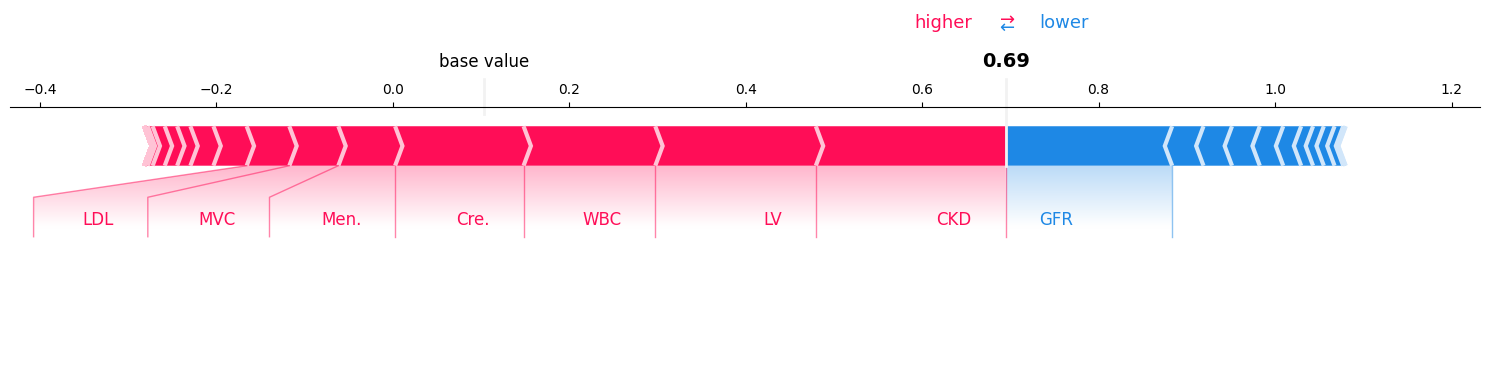

00:00 Predicting... -

/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py:218: UserWarning: Imputation-based SHAP would benefit substantially from the KV cache, but the tabpfn-client backend does not currently support it. Install the local tabpfn package (`pip install tabpfn`) and use TabPFNClassifier/TabPFNRegressor with fit_mode='fit_with_cache' to enable it.
  return fn(*args, **kwargs)


00:00 Predicting... \

Test set already exists, skipping upload.


00:07 Predicting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:07 Predicting... Done!
Computing pairwise Shapley interactions (k-SII, 1 row, budget=256)...


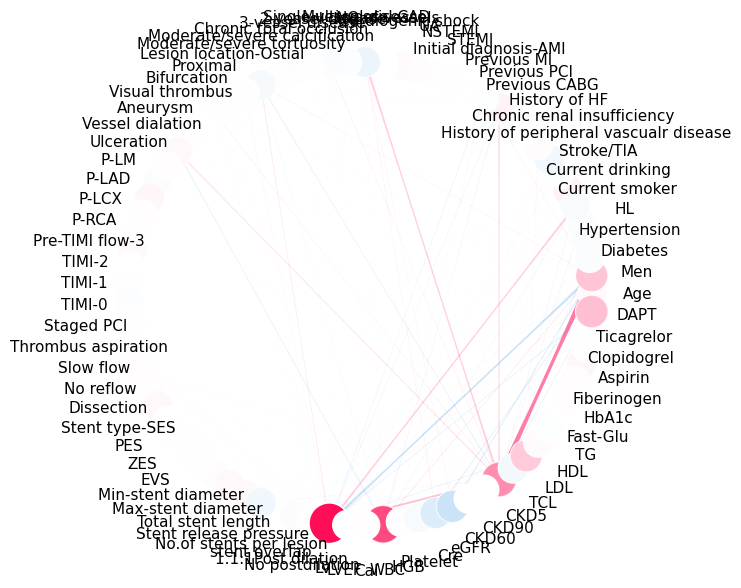

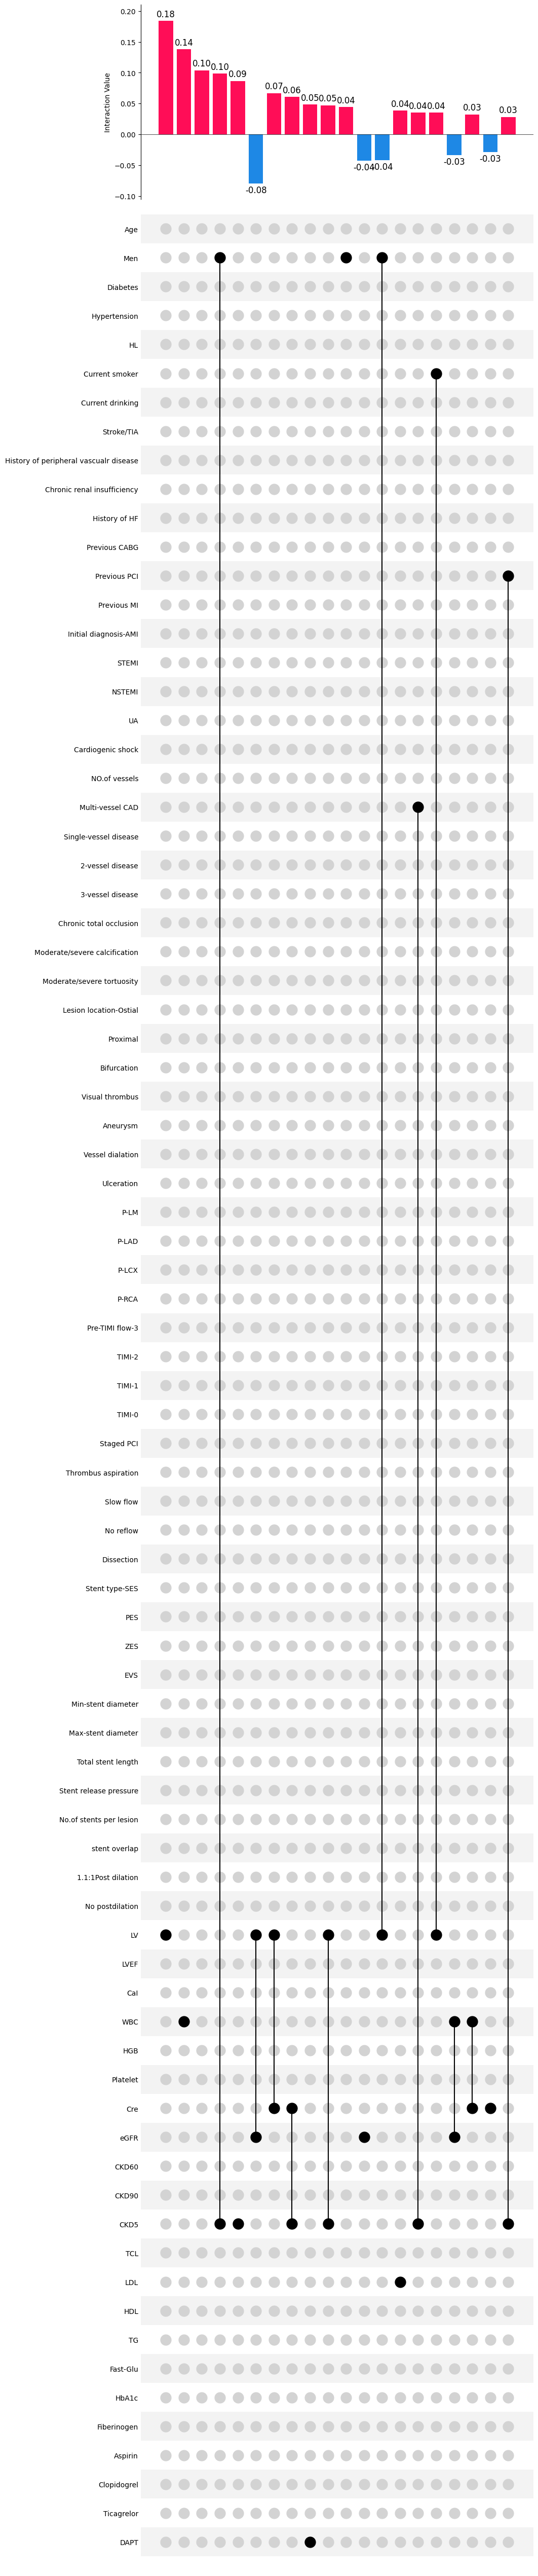

[4/5] done in 305.8s


In [8]:
"""Shapley values + pairwise Shapley interactions for the VLST TabPFN
classifier using the shapiq library, visualized with shapiq's native
plots.

Two paradigms for "feature removal" are illustrated:

  1. Imputation-based (`get_tabpfn_imputation_explainer`): masked
     features are filled by an imputer (default: baseline -- mean for
     numeric features, mode for categorical, learned from `data`). The
     training set is fixed across coalitions, so the KV-cache fast path
     applies -- construct the model with `fit_mode="fit_with_cache"`.

  2. Remove-and-recontextualize (`get_tabpfn_explainer`): TabPFN is
     re-fit on each coalition's column subset. Does not benefit from
     the KV cache (one predict per fit). Left commented out below --
     prohibitive at VLST's dimensionality.

For classifiers, both explainers default to `class_index=1`, i.e. they
explain P(positive) -- "Stent thrombosis" on VLST.
"""

from __future__ import annotations

import time
import warnings

from sklearn.model_selection import train_test_split

from tabpfn_client import TabPFNClassifier
from tabpfn_extensions.interpretability import shapiq as tabpfn_shapiq

print("=" * 60)
print("[4/5] SHAP-IQ (native shapiq plots)")
print("=" * 60)

_t0 = time.perf_counter()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

# Interaction/network/upset plots are most informative on a minority-class
# row when one exists; fall back to the first row otherwise.
_pos = np.where(y_test == 1)[0]
x_explain = X_test[_pos[0] if len(_pos) else 0]

def _make_iq_clf(**extra):
    return TabPFNClassifier(
        thinking_mode=INTERP_THINKING_MODE,
        thinking_effort=INTERP_THINKING_EFFORT,
        thinking_metric=INTERP_THINKING_METRIC,
        random_state=42,
    )

print("Fitting TabPFN for SHAP-IQ (1 thinking fit)...")
try:
    clf = _silence_client_progress(_make_iq_clf(fit_mode="fit_with_cache"))
    with _quiet_tabpfn_client():
        clf.fit(X_train, y_train)
except (TypeError, ValueError, NotImplementedError):
    warnings.warn(
        "shapiq would benefit substantially from the KV cache, but the "
        "current TabPFN install doesn't support fit_mode='fit_with_cache'. "
        "Falling back to the default constructor.",
        UserWarning, stacklevel=2,
    )
    clf = _silence_client_progress(_make_iq_clf())
    with _quiet_tabpfn_client():
        clf.fit(X_train, y_train)

# VLST has ~50 features; 2**d exact enumeration is intractable -- use
# sampled coalitions. Interactions (max_order=2) generally need a bigger
# budget than plain SV. Keep budgets at 256 (do not duplicate SHAP's
# expensive multi-row work -- this section is one-row native plots).
SV_BUDGET = 256
KSII_BUDGET = 256


# -----------------------------------------------------------------------------
# 1. Imputation-based explainer (uses the KV cache)
# -----------------------------------------------------------------------------
imputation_explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=clf,
    data=X_train,
    index="SV",     # plain Shapley values
    imputer="baseline",
    max_order=1,
)
print(f"Computing imputation-based Shapley values (1 row, budget={SV_BUDGET})...")
with _quiet_tabpfn_client():
    sv_imp = imputation_explainer.explain(x=x_explain, budget=SV_BUDGET)
sv_imp.plot_force(feature_names=list(feature_names))


# -----------------------------------------------------------------------------
# 2. Pairwise Shapley interactions via the same explainer (k-SII, max_order=2)
# -----------------------------------------------------------------------------
interaction_explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=clf,
    data=X_train,
    index="k-SII",  # k-Shapley Interaction Index -- extends SHAP to interactions
    imputer="baseline",
    max_order=2,
)
print(f"Computing pairwise Shapley interactions (k-SII, 1 row, budget={KSII_BUDGET})...")
with _quiet_tabpfn_client():
    iv_interactions = interaction_explainer.explain(x=x_explain, budget=KSII_BUDGET)

# Network plot: features as nodes sized by individual SV; edges colored by
# pairwise interaction strength. Specific to shapiq (not in the shap library).
iv_interactions.plot_network(feature_names=list(feature_names))

# Upset plot of top interactions.
iv_interactions.plot_upset(feature_names=list(feature_names))


# -----------------------------------------------------------------------------
# 3. Remove-and-recontextualize (Rundel) -- much slower, no KV cache.
# -----------------------------------------------------------------------------
# Each coalition triggers a fresh TabPFN fit on a different column subset,
# followed by exactly one predict. On VLST-sized d this is prohibitive.
# Kept as reference -- uncomment only for small feature subsets.

# rundel_explainer = tabpfn_shapiq.get_tabpfn_explainer(
#     model=clf,
#     data=X_train,
#     labels=y_train,
#     index="SV",
#     max_order=1,
# )
# sv_rundel = rundel_explainer.explain(x=x_explain, budget=SV_BUDGET)
# sv_rundel.plot_force(feature_names=list(feature_names))

_elapsed = time.perf_counter() - _t0
print(f"[4/5] done in {_elapsed:.1f}s")




### Feature importance report — [5/5]

Honest, consensus ranking of the most important features. No single method is
trusted alone — we aggregate the local, leakage-aware signals computed above:

1. **mutual_info_classif** — univariate association
2. **TabPFN forward SFS** — model-native single-run selection
3. **Stability selection frequency** — how often forward SFS keeps a feature
   across `STABILITY_N_SEEDS` resamples (the reliability signal)
4. **SHAP mean(|value|)** — model attribution magnitude on held-out rows

Ranking uses **Borda-style mean of normalized ranks** across the available
continuous signals (robust to any one noisy method), with `n_methods` (out of
4) as a consensus column. Report the **top 15** as *associations* with stent
thrombosis under TabPFN — exploratory, not causal, on a ~2% prevalence cohort.
→ `interpretability_feature_importance_report.csv` + `.png`

[5/5] Feature importance report (consensus)

Aggregated from signals: ['mutual_info', 'selection_freq', 'shap_mean_abs']

Top 15 features (honest consensus ranking):
 rank                 feature  importance_score  n_methods  selection_freq  shap_mean_abs  mutual_info  in_mi_top  in_forward_sfs  in_shap_top
    1                     WBC          0.981250          4             1.0       0.108137     0.018360       True            True         True
    2                      LV          0.981250          3             1.0       0.109012     0.015178       True           False         True
    3                    eGFR          0.960417          3             1.0       0.097589     0.009931       True           False         True
    4          Stent type-SES          0.943750          3             1.0       0.035634     0.011357       True           False         True
    5         No postdilation          0.916667          3             0.6       0.053144     0.007535       True      

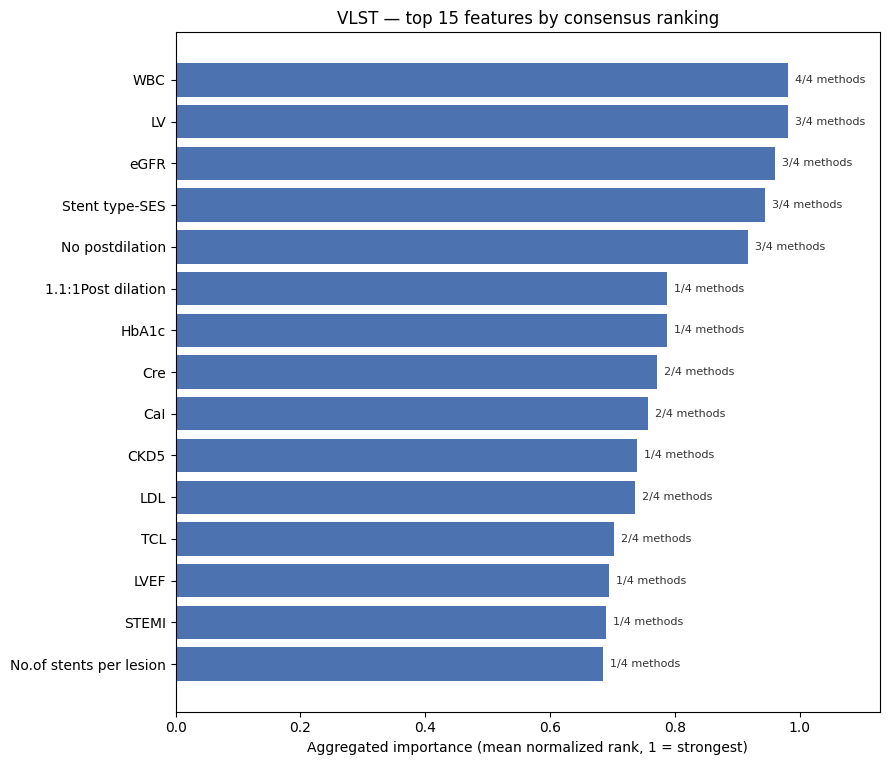

Saved: /kaggle/working/modeling_tabpfn/interpretability_feature_importance_report.png


In [9]:
"""Honest feature-importance report for VLST — consensus of local signals.

Combines mutual_info, forward SFS membership, stability-selection frequency,
and SHAP mean(|value|) into one ranked table. Ranking = Borda-style mean of
normalized ranks over the available continuous signals; `n_methods` counts how
many methods flag each feature. Report the TOP_K as *associations* with stent
thrombosis under TabPFN — exploratory, not causal, on a ~2% prevalence cohort.
Reads only CSV artifacts, so it costs 0 thinking fits and can be re-run freely.
"""

from __future__ import annotations

import matplotlib.pyplot as plt

print("=" * 60)
print("[5/5] Feature importance report (consensus)")
print("=" * 60)

TOP_K = 15

_report_csv = RESULT_DIR / "interpretability_feature_importance_report.csv"
_report_png = RESULT_DIR / "interpretability_feature_importance_report.png"

_mi_csv = RESULT_DIR / "interpretability_mutual_info_ranking.csv"
_fs_forward = RESULT_DIR / "interpretability_forward_feature_selection.csv"
_stab_csv = RESULT_DIR / "interpretability_feature_stability.csv"
_shap_csv = RESULT_DIR / "interpretability_shap_mean_abs.csv"

_report = pd.DataFrame({"feature": list(feature_names)})
_signals = []  # continuous columns used for rank aggregation

# --- mutual information ---------------------------------------------------
if _mi_csv.is_file():
    _mi = pd.read_csv(_mi_csv)[["feature", "mutual_info"]]
    _report = _report.merge(_mi, on="feature", how="left")
    _report["mutual_info"] = _report["mutual_info"].fillna(0.0)
    _report["in_mi_top"] = _report["feature"].isin(_mi["feature"])
    _signals.append("mutual_info")
else:
    print(f"WARN: {_mi_csv.name} missing — run [1/5] first.")
    _report["mutual_info"] = 0.0
    _report["in_mi_top"] = False

# --- stability selection frequency ---------------------------------------
if _stab_csv.is_file():
    _stab = pd.read_csv(_stab_csv)[["feature", "selection_freq"]]
    _report = _report.merge(_stab, on="feature", how="left")
    _report["selection_freq"] = _report["selection_freq"].fillna(0.0)
    _signals.append("selection_freq")
else:
    print(f"WARN: {_stab_csv.name} missing — run [1/5] stability step first.")
    _report["selection_freq"] = 0.0

# --- SHAP mean(|value|) --------------------------------------------------
if _shap_csv.is_file():
    _shap = pd.read_csv(_shap_csv)[["feature", "shap_mean_abs"]]
    _report = _report.merge(_shap, on="feature", how="left")
    _report["shap_mean_abs"] = _report["shap_mean_abs"].fillna(0.0)
    _shap_top = set(
        _shap.sort_values("shap_mean_abs", ascending=False).head(TOP_K)["feature"]
    )
    _report["in_shap_top"] = _report["feature"].isin(_shap_top)
    _signals.append("shap_mean_abs")
else:
    print(f"WARN: {_shap_csv.name} missing — run [3/5] SHAP first.")
    _report["shap_mean_abs"] = 0.0
    _report["in_shap_top"] = False

# --- forward SFS membership ----------------------------------------------
if _fs_forward.is_file():
    _fwd = pd.read_csv(_fs_forward)["feature"].tolist()
    _report["in_forward_sfs"] = _report["feature"].isin(_fwd)
else:
    print(f"WARN: {_fs_forward.name} missing — run [1/5] first.")
    _report["in_forward_sfs"] = False

# --- consensus count (out of 4 methods) ----------------------------------
_report["n_methods"] = (
    _report["in_mi_top"].astype(int)
    + _report["in_forward_sfs"].astype(int)
    + (_report["selection_freq"] >= 0.5).astype(int)
    + _report["in_shap_top"].astype(int)
)

# --- Borda rank aggregation over available continuous signals ------------
if _signals:
    _norm = []
    for _c in _signals:
        _r = _report[_c].rank(method="average", ascending=True)  # 1 = best
        _norm.append((_r - 1) / max(len(_report) - 1, 1))
    _report["importance_score"] = np.mean(_norm, axis=0)
else:
    print("WARN: no continuous signals available — cannot rank.")
    _report["importance_score"] = 0.0

_report = _report.sort_values(
    ["importance_score", "n_methods"], ascending=[False, False]
).reset_index(drop=True)
_report.insert(0, "rank", range(1, len(_report) + 1))

_cols = [
    "rank", "feature", "importance_score", "n_methods",
    "selection_freq", "shap_mean_abs", "mutual_info",
    "in_mi_top", "in_forward_sfs", "in_shap_top",
]
_report = _report[[c for c in _cols if c in _report.columns]]
_report.to_csv(_report_csv, index=False)

_topk = _report.head(TOP_K)
print(f"\nAggregated from signals: {_signals}")
print(f"\nTop {TOP_K} features (honest consensus ranking):")
print(_topk.to_string(index=False))
print(f"\nSaved: {_report_csv}")

# --- horizontal bar chart of top-k --------------------------------------
_bars = _topk.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 0.45 * len(_bars) + 1))
ax.barh(_bars["feature"], _bars["importance_score"], color="#4C72B0")
for _i, (_score, _n) in enumerate(zip(_bars["importance_score"], _bars["n_methods"])):
    ax.text(_score, _i, f"  {_n}/4 methods", va="center", fontsize=8, color="#333")
ax.set_xlabel("Aggregated importance (mean normalized rank, 1 = strongest)")
ax.set_title(f"VLST — top {TOP_K} features by consensus ranking")
ax.margins(x=0.15)
fig.tight_layout()
fig.savefig(_report_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_report_png}")
